# CNeuroMod QA — MRIQC metrics

Raincloud distributions of per-run image-quality metrics (framewise displacement, tSNR) across subjects and datasets, read from `output_data/tables/`. Figures are written to `output_data/figures/qc_measures/`.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np  # noqa: F401
import pandas as pd
import seaborn as sns

try:
    import ptitprince
    HAS_PTITPRINCE = True
except Exception:
    HAS_PTITPRINCE = False

# Paths are provided by `invoke run-notebooks` as environment variables.
# Figures go in output_data/figures/{FIG_NAME}/ (also the notebook's "already
# ran" sentinel); the metric tables live in output_data/tables/.
FIG_NAME = "qc_measures"
OUTPUT_DIR = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data"))
FIG_DIR = OUTPUT_DIR / "figures" / FIG_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_tables(subdir):
    """Concatenate every non-empty TSV in output_data/<subdir>/."""
    frames = []
    for path in sorted((OUTPUT_DIR / subdir).glob("*.tsv")):
        try:
            frame = pd.read_csv(path, sep="\t")
        except (pd.errors.EmptyDataError, OSError):
            continue
        if not frame.empty:
            frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# --- House figure style (dataviz skill) --------------------------------------
# Colour is assigned by the job it does and checked with the skill's validator:
#   * per-run distributions are already labelled on the x-axis, so the marks use
#     ONE recessive hue instead of a decorative rainbow;
#   * the motion-band severity scale uses the reserved status colours
#     (good / warning / critical), CVD-checked as an ordered, gap-separated stack.
HUE = "#2a78d6"      # single categorical hue (blue, slot 1)
INK = "#0b0b0b"      # primary ink
MUTED = "#898781"    # axis + tick labels (recessive)
GRID = "#e1e0d9"     # hairline gridline

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": MUTED,
    "axes.linewidth": 0.8,
    "axes.titlesize": 12,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.family": "sans-serif",
})


def style_axes(ax):
    """Recessive chrome: drop top/right spines, hairline y-grid, ticks behind."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    return ax


In [2]:
def raincloud(data, x, y, ax, color=None, ascending=True):
    """Half-violin + jittered strip in a single recessive hue (no boxplot).

    A full RainCloud stacks a half-violin, a boxplot, and a strip; we drop the
    box and compose the two remaining layers directly (ptitprince exposes
    `half_violinplot` and `stripplot`), with a seaborn fallback. The category is
    already named on the x-axis, so colour would carry no extra information; one
    hue keeps the ink recessive (dataviz skill).

    Categories are ordered along the x-axis by their median `y`: `ascending=True`
    (default) runs least-to-most left-to-right, the natural reading for FD-style
    "lower is better" metrics; pass `ascending=False` for tSNR, where higher is
    better, so the best sits on the left and the worst on the right."""
    color = HUE if color is None else color
    data = data[[x, y]].dropna()
    if data.empty:
        ax.set_title(f"no data for {y}")
        return ax
    order = (data.groupby(x)[y].median()
                 .sort_values(ascending=ascending).index.tolist())
    n = max(data[x].nunique(), 1)
    if HAS_PTITPRINCE:
        try:
            ptitprince.half_violinplot(x=x, y=y, data=data, order=order,
                                       palette=[color] * n, bw=.15, width=.9,
                                       ax=ax, orient="v", inner=None, offset=-.05)
            ptitprince.stripplot(x=x, y=y, data=data, order=order,
                                 palette=[color] * n, ax=ax, orient="v", move=.2,
                                 size=2, alpha=.65, edgecolor="white", linewidth=.3)
            if ax.get_legend():
                ax.get_legend().remove()
            return style_axes(ax)
        except Exception:
            ax.clear()
    sns.violinplot(data=data, x=x, y=y, ax=ax, order=order, color=color,
                   inner=None, cut=0)
    sns.stripplot(data=data, x=x, y=y, ax=ax, order=order, color=INK, size=2,
                  alpha=.35)
    return style_axes(ax)

In [3]:
qc = load_tables("tables")
print(f"loaded {len(qc)} runs")
if qc.empty:
    print("No QC metrics found — run `invoke run-qc-measures` first "
          "(needs data access).")
qc.head()

loaded 4503 runs


,dataset,subject,session,task,run,task_grouped,fd_mean,fd_num,fd_perc,tsnr,...,gsr_x,gsr_y,dvars_std,dvars_vstd,aor,aqi,gcor,size_t,fd_prop_gt02,fd_prop_gt05
0,floc,1,1.0,fLoc,1.0,fLoc,0.095655,4,2.580645,34.775093,...,-0.007330,0.092868,1.096233,1.014164,0.001235,0.005645,0.005919,155,0.025806,0.000000
1,floc,1,1.0,fLoc,2.0,fLoc,0.092470,3,1.935484,33.385800,...,-0.007088,0.094252,1.059803,0.989887,0.000598,0.006511,0.006913,155,0.019355,0.000000
2,floc,1,2.0,fLoc,1.0,fLoc,0.107802,8,5.194805,32.012708,...,-0.010132,0.095128,1.058638,0.992889,0.000651,0.007349,0.004041,154,0.051948,0.000000
3,floc,1,2.0,fLoc,2.0,fLoc,0.101230,12,7.792208,34.056397,...,-0.009027,0.094537,1.086857,1.020901,0.001314,0.005971,0.005213,154,0.077922,0.000000
4,floc,1,3.0,fLoc,1.0,fLoc,0.115155,11,7.142857,30.349011,...,-0.012415,0.096275,1.063736,1.007480,0.001540,0.009845,0.003522,154,0.071429,0.006494


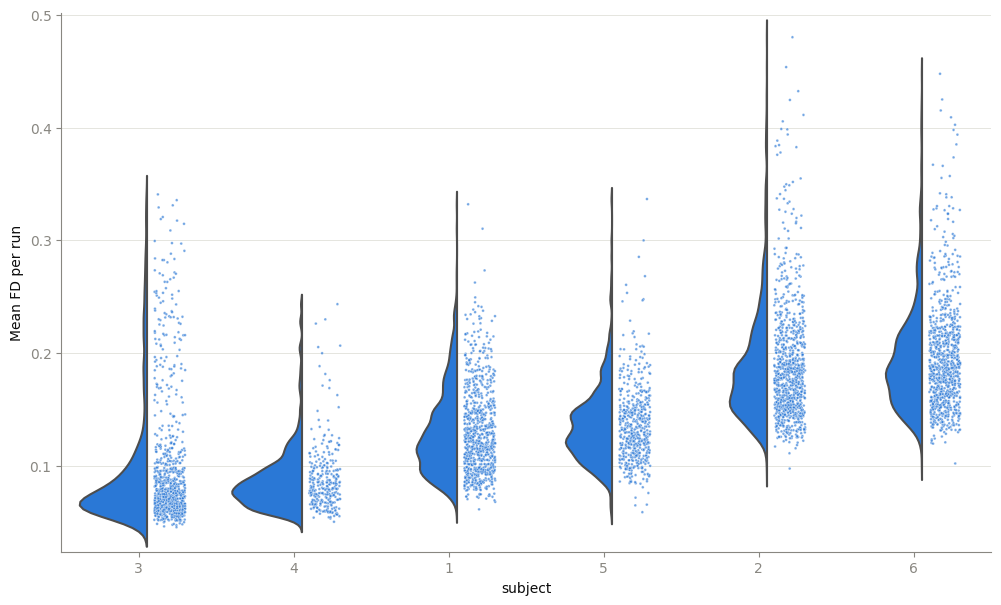

In [4]:
if not qc.empty:
    fig, ax = plt.subplots(figsize=(12, 7))
    raincloud(qc, "subject", "fd_mean", ax)
    ax.set_xlabel("subject")
    ax.set_ylabel("Mean FD per run")
    fig.savefig(FIG_DIR / "fd_mean_by_subject.png", dpi=120, bbox_inches="tight")

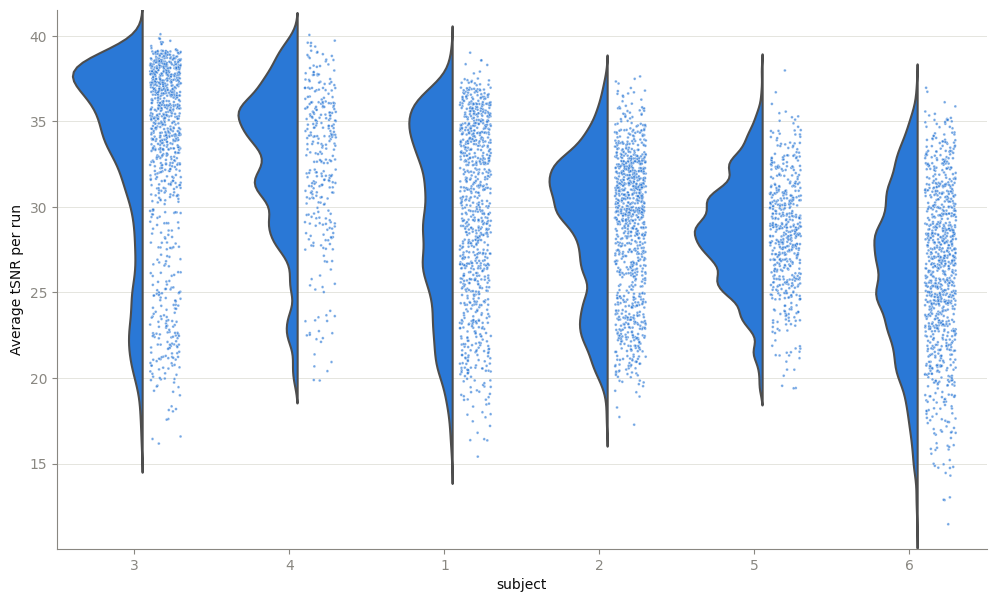

In [5]:
if not qc.empty:
    fig, ax = plt.subplots(figsize=(12, 7))
    raincloud(qc, "subject", "tsnr", ax, ascending=False)
    ax.set_xlabel("subject")
    ax.set_ylabel("Average tSNR per run")
    fig.savefig(FIG_DIR / "tsnr_by_subject.png", dpi=120, bbox_inches="tight")

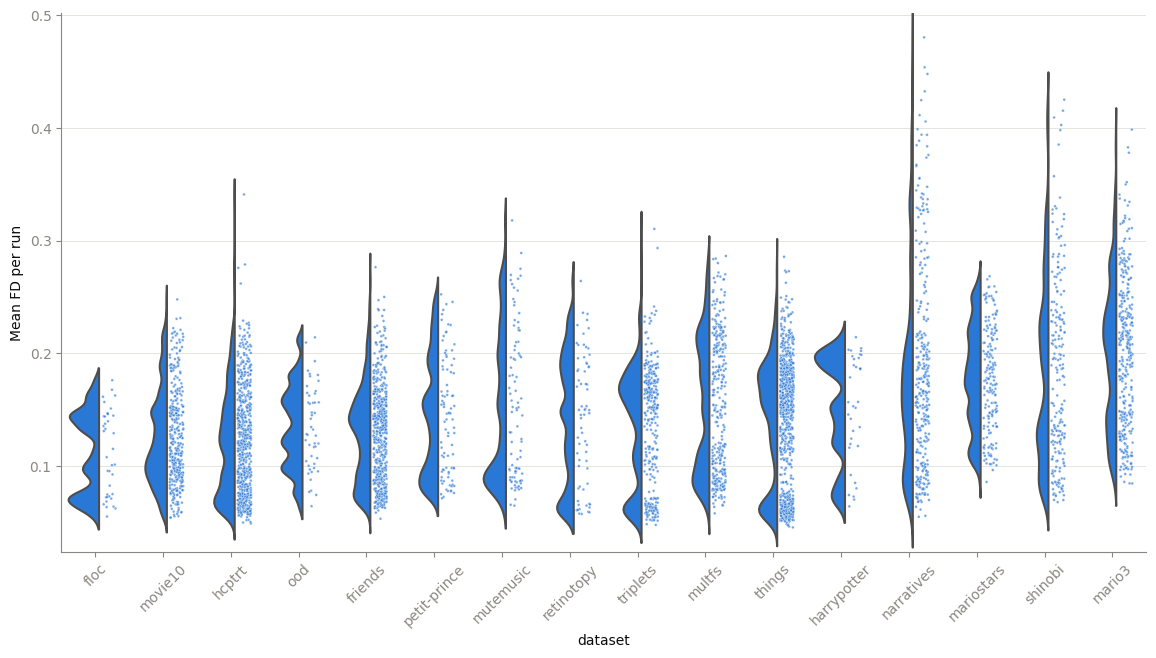

In [6]:
if not qc.empty and qc["dataset"].notna().any():
    fig, ax = plt.subplots(figsize=(14, 7))
    raincloud(qc, "dataset", "fd_mean", ax)
    ax.tick_params("x", labelrotation=45)
    ax.set_xlabel("dataset")
    ax.set_ylabel("Mean FD per run")
    fig.savefig(FIG_DIR / "fd_mean_by_dataset.png", dpi=120, bbox_inches="tight")

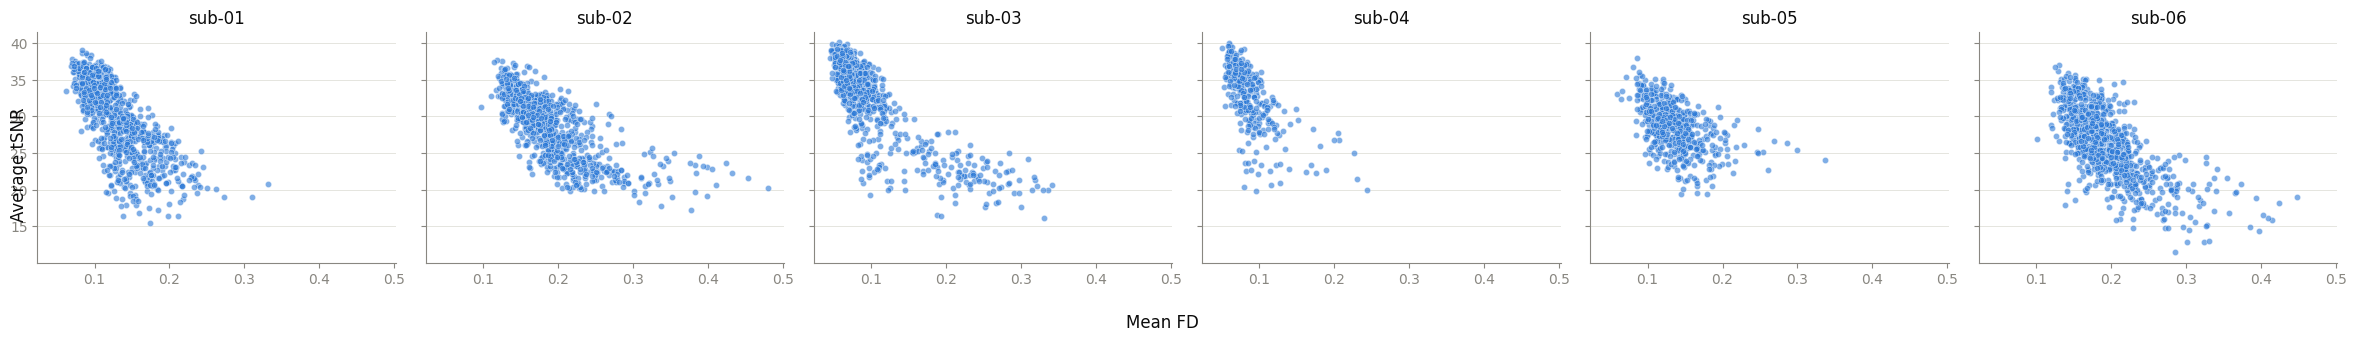

In [7]:
if not qc.empty and qc[["fd_mean", "tsnr"]].dropna().shape[0] > 0:
    # One panel per subject (small multiples), all on a single row: subject
    # identity is carried by facet position, not colour. Six categorical hues on
    # a single scatter fail the dataviz colour-blind separation check (validated:
    # green vs orange ΔE 3.2); faceting sidesteps it while keeping every subject
    # legible.
    subjects = sorted(qc["subject"].dropna().unique())
    ncols = len(subjects)
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 3.4),
                             squeeze=False, sharex=True, sharey=True)
    flat_axes = axes.flatten()
    for ax, subject in zip(flat_axes, subjects):
        sub = qc[qc["subject"] == subject]
        ax.scatter(sub["fd_mean"], sub["tsnr"], s=20, color=HUE, alpha=.6,
                   edgecolor="white", linewidth=.4)
        ax.set_title(f"sub-{int(subject):02d}")
        style_axes(ax)
    fig.supxlabel("Mean FD")
    fig.supylabel("Average tSNR")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fd_vs_tsnr.png", dpi=120, bbox_inches="tight")


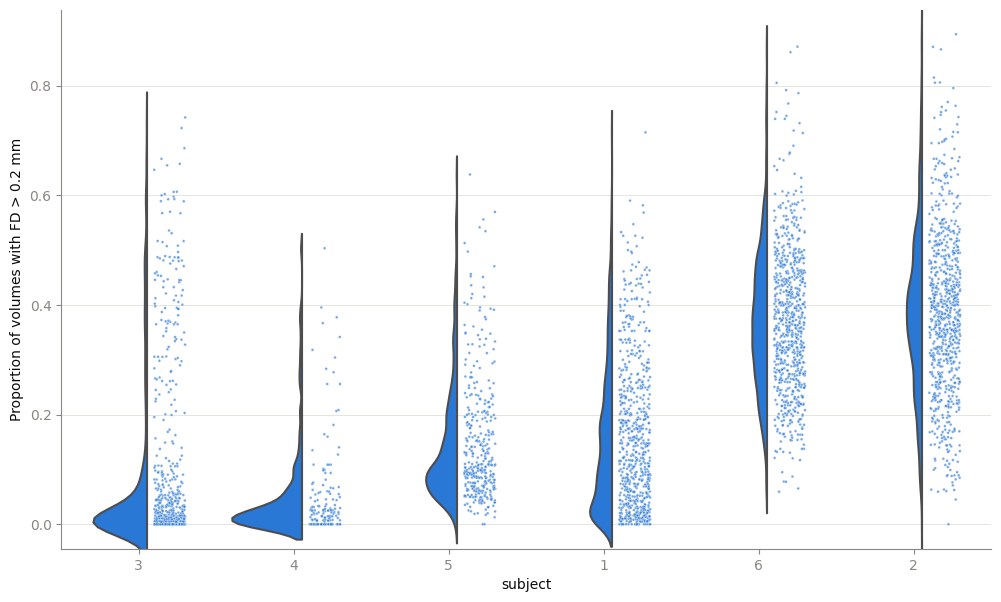

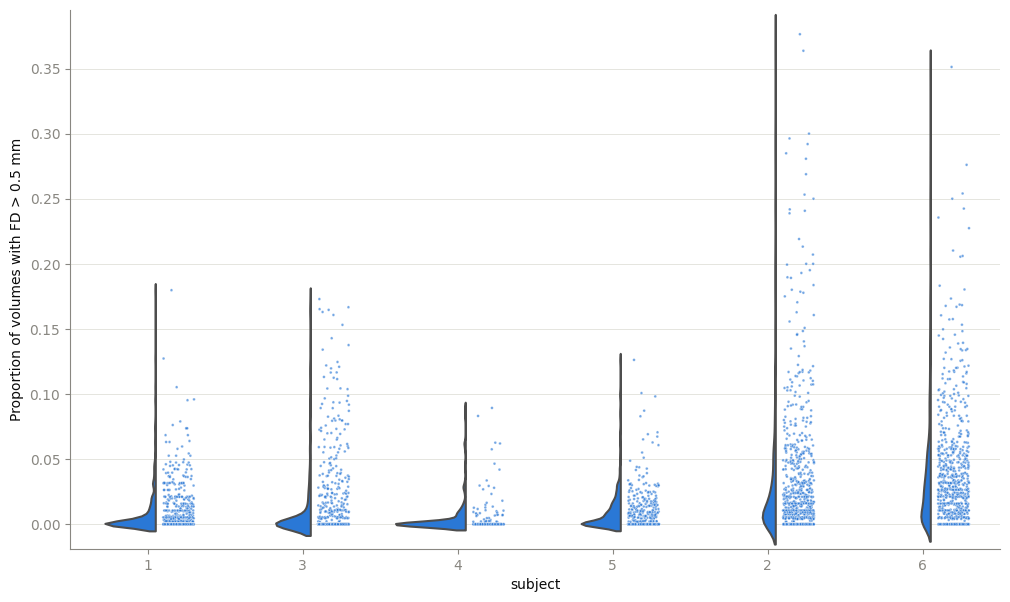

In [8]:
for col, thr in [("fd_prop_gt02", 0.2), ("fd_prop_gt05", 0.5)]:
    if not qc.empty and col in qc and qc[col].notna().any():
        fig, ax = plt.subplots(figsize=(12, 7))
        raincloud(qc, "subject", col, ax)
        ax.set_xlabel("subject")
        ax.set_ylabel(f"Proportion of volumes with FD > {thr} mm")
        fig.savefig(FIG_DIR / f"{col}_by_subject.png", dpi=120,
                    bbox_inches="tight")